## 1. Setup

Install once in a fresh environment:

```python
!pip install fredapi pandas numpy matplotlib statsmodels scikit-learn python-dotenv -q
```

This notebook is designed for a local Python virtual environment.

In [65]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
from sklearn.metrics import roc_auc_score, roc_curve
from fredapi import Fred
from dotenv import load_dotenv

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.max_columns", 50)

plt.rcParams.update({
    "figure.figsize": (11, 5),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

load_dotenv()

print("Environment ready.")

Environment ready.


## 2. FRED API key

The environment variable is preferred, but the explicit fallback is retained for this private/local project.

For a public repository, rotate the key and move it to a gitignored `.env` file.

In [ ]:
FRED_API_KEY = os.environ.get(
    "FRED_API_KEY"
)

fred = Fred(api_key=FRED_API_KEY)

try:
    _test = fred.get_series("INDIRLTLT01STM").dropna()
    print(
        f"FRED connection OK. Test series has {len(_test)} observations; "
        f"latest = {_test.index[-1].date()} -> {_test.iloc[-1]:.2f}"
    )
except Exception as exc:
    raise RuntimeError(
        "Could not reach the FRED API. Check internet access and the FRED API key."
    ) from exc

FRED connection OK. Test series has 174 observations; latest = 2026-05-01 -> 7.02


## 3. Data acquisition

### Series definitions

| Concept | FRED ID | Units | Transformation used |
|---|---|---|---|
| 10Y G-Sec yield | `INDIRLTLT01STM` | percent | used as level |
| 3M interbank rate | `INDIR3TIB01STM` | percent | used as level |
| CPI all-items index | `INDCPIALLMINMEI` | index, 2015=100 | YoY inflation = 12-month percent change |
| Manufacturing production growth | `INDPRMNTO01GYSAM` | percent YoY, seasonally adjusted | used directly |

The manufacturing series is already a year-on-year growth rate, so applying `pct_change(12)` to it would be a double transformation and is intentionally avoided.

The CPI series is archived through March 2025. The study therefore uses the common historical sample rather than forcing a false current-data claim.

In [67]:
SERIES = {
    "gsec_10y": ("INDIRLTLT01STM", "10Y G-Sec Yield (%)"),
    "short_rate": ("INDIR3TIB01STM", "3M Interbank Rate (%)"),
    "cpi_index": ("INDCPIALLMINMEI", "CPI Index (2015=100)"),
    "growth_yoy": ("INDPRMNTO01GYSAM", "Manufacturing Production YoY (%)"),
}

def fetch_fred_series(series_id, label, start="2010-01-01"):
    series = fred.get_series(series_id, observation_start=start).dropna()
    if series.empty:
        raise ValueError(f"{series_id} returned no observations.")
    series.index = pd.to_datetime(series.index)
    series.name = label
    print(
        f"[{label}] {series_id}: {len(series)} observations, "
        f"{series.index.min().date()} -> {series.index.max().date()}"
    )
    return series

raw = {
    key: fetch_fred_series(series_id, label)
    for key, (series_id, label) in SERIES.items()
}

print("\nSeries actually used:")
for key, (series_id, label) in SERIES.items():
    print(f"  {key}: {series_id}")

[10Y G-Sec Yield (%)] INDIRLTLT01STM: 174 observations, 2011-12-01 -> 2026-05-01
[3M Interbank Rate (%)] INDIR3TIB01STM: 175 observations, 2011-11-01 -> 2026-05-01
[CPI Index (2015=100)] INDCPIALLMINMEI: 183 observations, 2010-01-01 -> 2025-03-01
[Manufacturing Production YoY (%)] INDPRMNTO01GYSAM: 196 observations, 2010-01-01 -> 2026-04-01

Series actually used:
  gsec_10y: INDIRLTLT01STM
  short_rate: INDIR3TIB01STM
  cpi_index: INDCPIALLMINMEI
  growth_yoy: INDPRMNTO01GYSAM


### Data-alignment policy

All monthly observations are normalized to month-start.

We do **not** blindly extend one series through stale gaps. Instead, each series is aligned to the common calendar and only isolated one-month missing gaps are forward-filled. The final analysis then uses complete observations.

For forecasting interpretation, predictors are lagged one month so that a month-*t* predictor is not implicitly treated as known on the first day of month *t*.

In [68]:
monthly_index = pd.date_range(
    start=min(s.index.min() for s in raw.values()).to_period("M").to_timestamp(),
    end=max(s.index.max() for s in raw.values()).to_period("M").to_timestamp(),
    freq="MS",
)

df = pd.DataFrame(index=monthly_index)

for key, series in raw.items():
    s = series.copy()
    s.index = s.index.to_period("M").to_timestamp(how="start")
    s = s.groupby(level=0).last()
    df[key] = s.reindex(monthly_index).ffill(limit=1)

print("Combined frame shape:", df.shape)
print("\nMissing values per column:")
print(df.isna().sum())

display(df.tail())

Combined frame shape: (197, 4)

Missing values per column:
gsec_10y      23
short_rate    22
cpi_index     13
growth_yoy     0
dtype: int64


,gsec_10y,short_rate,cpi_index,growth_yoy
2026-01-01,6.7320,5.4111,NaN,5.1260
2026-02-01,6.7700,5.3200,NaN,5.9343
2026-03-01,6.8400,5.3200,NaN,3.7429
2026-04-01,7.0500,5.2400,NaN,6.2746
2026-05-01,7.0200,5.3900,NaN,6.2746


## 4. RBI repo-rate change history

Only meetings that changed the policy rate are listed. Holds are implicit.

The forward-cut target is only calculated for months whose six-month future window is fully covered by the hand-compiled policy history. This prevents late-sample zeros caused by an incomplete event window.

In [69]:
repo_changes = pd.DataFrame([
    ("2011-05-03", 6.75, 7.25, "hike"),
    ("2011-06-16", 7.25, 7.50, "hike"),
    ("2011-07-26", 7.50, 8.00, "hike"),
    ("2011-09-16", 8.00, 8.25, "hike"),
    ("2011-10-25", 8.25, 8.50, "hike"),
    ("2012-04-17", 8.50, 8.00, "cut"),
    ("2013-01-29", 8.00, 7.75, "cut"),
    ("2013-03-19", 7.75, 7.50, "cut"),
    ("2013-05-03", 7.50, 7.25, "cut"),
    ("2013-09-20", 7.25, 7.50, "hike"),
    ("2013-10-29", 7.50, 7.75, "hike"),
    ("2014-01-28", 7.75, 8.00, "hike"),
    ("2015-01-15", 8.00, 7.75, "cut"),
    ("2015-03-04", 7.75, 7.50, "cut"),
    ("2015-06-02", 7.50, 7.25, "cut"),
    ("2015-09-29", 7.25, 6.75, "cut"),
    ("2016-04-05", 6.75, 6.50, "cut"),
    ("2016-10-04", 6.50, 6.25, "cut"),
    ("2017-08-02", 6.25, 6.00, "cut"),
    ("2018-06-06", 6.00, 6.25, "hike"),
    ("2018-08-01", 6.25, 6.50, "hike"),
    ("2019-02-07", 6.50, 6.25, "cut"),
    ("2019-04-04", 6.25, 6.00, "cut"),
    ("2019-06-06", 6.00, 5.75, "cut"),
    ("2019-08-07", 5.75, 5.40, "cut"),
    ("2019-10-04", 5.40, 5.15, "cut"),
    ("2020-03-27", 5.15, 4.40, "cut"),
    ("2020-05-22", 4.40, 4.00, "cut"),
    ("2022-05-04", 4.00, 4.40, "hike"),
    ("2022-06-08", 4.40, 4.90, "hike"),
    ("2022-08-05", 4.90, 5.40, "hike"),
    ("2022-09-30", 5.40, 5.90, "hike"),
    ("2022-12-07", 5.90, 6.25, "hike"),
    ("2023-02-08", 6.25, 6.50, "hike"),
    ("2025-02-07", 6.50, 6.25, "cut"),
    ("2025-04-09", 6.25, 6.00, "cut"),
    ("2025-06-06", 6.00, 5.50, "cut"),
    ("2025-12-05", 5.50, 5.25, "cut"),
], columns=["date", "old_rate", "new_rate", "direction"])

repo_changes["date"] = pd.to_datetime(repo_changes["date"])
repo_changes = repo_changes.sort_values("date").reset_index(drop=True)

print(
    f"{len(repo_changes)} policy changes on record: "
    f"{(repo_changes['direction'] == 'cut').sum()} cuts / "
    f"{(repo_changes['direction'] == 'hike').sum()} hikes."
)

display(repo_changes.tail(10))

38 policy changes on record: 22 cuts / 16 hikes.


,date,old_rate,new_rate,direction
28,2022-05-04,4.0000,4.4000,hike
29,2022-06-08,4.4000,4.9000,hike
30,2022-08-05,4.9000,5.4000,hike
31,2022-09-30,5.4000,5.9000,hike
32,2022-12-07,5.9000,6.2500,hike
33,2023-02-08,6.2500,6.5000,hike
34,2025-02-07,6.5000,6.2500,cut
35,2025-04-09,6.2500,6.0000,cut
36,2025-06-06,6.0000,5.5000,cut
37,2025-12-05,5.5000,5.2500,cut


## 5. Feature construction

The manufacturing FRED series is already YoY growth. CPI is converted from index to YoY inflation.

The term spread is:

`10Y government bond yield - 3M interbank rate`

For the predictive models, every predictor is lagged one month to reduce publication-timing leakage.

In [70]:
df["term_spread"] = df["gsec_10y"] - df["short_rate"]
df["cpi_yoy"] = df["cpi_index"].pct_change(12) * 100

# Predictors are lagged one month for an information-set-safe specification.
df["term_spread_lag1"] = df["term_spread"].shift(1)
df["cpi_yoy_lag1"] = df["cpi_yoy"].shift(1)

analysis_base = df.dropna(
    subset=["term_spread_lag1", "cpi_yoy_lag1", "growth_yoy"]
).copy()

print(
    f"Historical analysis sample: {analysis_base.index[0].date()} "
    f"to {analysis_base.index[-1].date()} "
    f"({len(analysis_base)} monthly observations)"
)

display(
    analysis_base[
        ["term_spread", "cpi_yoy", "growth_yoy",
         "term_spread_lag1", "cpi_yoy_lag1"]
    ].describe()
)

Historical analysis sample: 2012-01-01 to 2025-05-01 (161 monthly observations)


,term_spread,cpi_yoy,growth_yoy,term_spread_lag1,cpi_yoy_lag1
count,161.0000,160.0000,161.0000,161.0000,161.0000
mean,0.8495,5.9339,3.8795,0.8466,5.9373
std,1.1023,2.3669,17.3821,1.1039,2.3599
min,-3.0060,1.0830,-66.7574,-3.0060,1.0830
25%,0.1166,4.4159,0.5773,0.1166,4.4187
50%,0.5191,5.6140,3.3918,0.5191,5.6140
75%,1.4191,6.9256,5.7128,1.4191,6.9124
max,3.1803,12.0603,194.5676,3.1803,12.0603


## 6. Growth slowdown definition

To avoid full-sample leakage, the slowdown threshold is calibrated using only observations available through December 2018.

The target variable is a month-level indicator equal to one when manufacturing YoY growth falls below the pre-calibrated bottom-tercile threshold. The predictors are lagged by one month.

In [71]:
SLOWDOWN_QUANTILE = 0.33
THRESHOLD_CALIBRATION_END = pd.Timestamp("2018-12-01")

# Calibrate the threshold only on historically available growth observations.
calibration = analysis_base.loc[
    analysis_base.index <= THRESHOLD_CALIBRATION_END,
    "growth_yoy",
].dropna()

if calibration.empty:
    raise RuntimeError("Slowdown-threshold calibration sample is empty.")

growth_threshold = calibration.quantile(SLOWDOWN_QUANTILE)

analysis_df = analysis_base.copy()

# The target at date t uses growth observed at date t.
# Predictors are separately lagged by one month.
analysis_df["is_slowdown"] = (
    analysis_df["growth_yoy"] < growth_threshold
).astype(int)

print(
    f"Slowdown threshold = {growth_threshold:.2f}% "
    f"(bottom {SLOWDOWN_QUANTILE:.0%} of the calibration window)"
)
print(f"Full-sample flagged share: {analysis_df['is_slowdown'].mean():.1%}")

Slowdown threshold = 1.74% (bottom 33% of the calibration window)
Full-sample flagged share: 32.9%


## 7. Exploratory plot

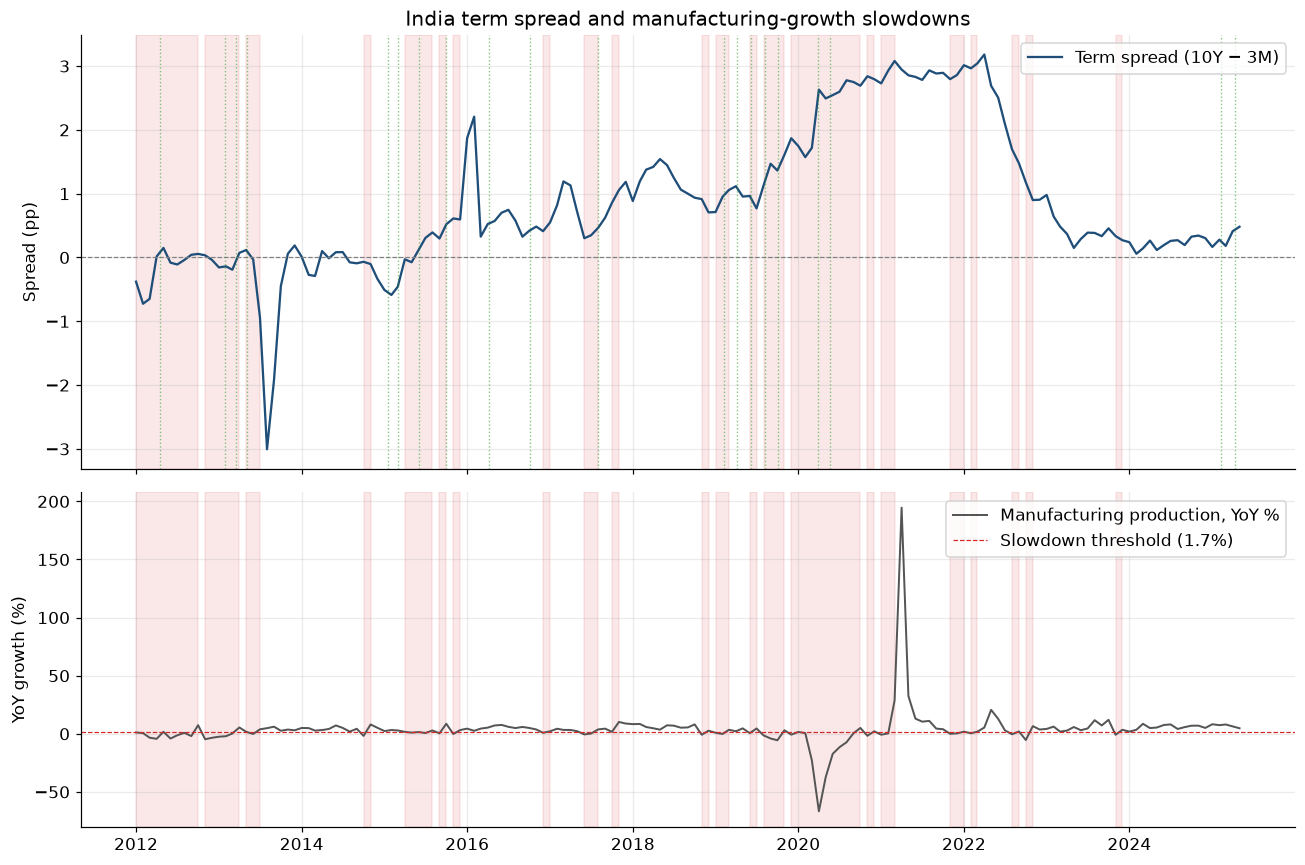

Red shading = slowdown months. Dotted green lines = RBI repo cuts.


In [72]:
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(12, 8), sharex=True,
    gridspec_kw={"height_ratios": [1.3, 1]}
)

ax1.plot(
    analysis_df.index,
    analysis_df["term_spread"],
    color="#1f4e79",
    lw=1.5,
    label="Term spread (10Y − 3M)"
)
ax1.axhline(0, color="gray", lw=0.8, ls="--")
ax1.set_ylabel("Spread (pp)")
ax1.set_title("India term spread and manufacturing-growth slowdowns")

in_slowdown = analysis_df["is_slowdown"].to_numpy()
dates = analysis_df.index
start = None

for i, flag in enumerate(in_slowdown):
    if flag and start is None:
        start = dates[i]
    if (not flag or i == len(in_slowdown) - 1) and start is not None:
        end = dates[i]
        ax1.axvspan(start, end, color="#d62728", alpha=0.10)
        ax2.axvspan(start, end, color="#d62728", alpha=0.10)
        start = None

cuts_in_range = repo_changes[
    (repo_changes["direction"] == "cut")
    & (repo_changes["date"] >= dates[0])
    & (repo_changes["date"] <= dates[-1])
]

for d in cuts_in_range["date"]:
    ax1.axvline(d, color="#2ca02c", lw=0.9, alpha=0.6, ls=":")

ax1.legend(loc="upper right")

ax2.plot(
    analysis_df.index,
    analysis_df["growth_yoy"],
    color="#555555",
    lw=1.3,
    label="Manufacturing production, YoY %"
)
ax2.axhline(
    growth_threshold,
    color="#d62728",
    lw=0.8,
    ls="--",
    label=f"Slowdown threshold ({growth_threshold:.1f}%)"
)
ax2.set_ylabel("YoY growth (%)")
ax2.legend(loc="upper right")
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "spread_vs_growth.png", bbox_inches="tight")
plt.show()

print("Red shading = slowdown months. Dotted green lines = RBI repo cuts.")

## 8. Baseline lead-logit test

The dependent variable is the slowdown indicator at `t + h`, while the predictor is the information-set-safe term spread at `t`.

HAC standard errors are used because the forward-looking targets overlap.

In [73]:
def run_lead_logit(
    df_in,
    predictor_cols,
    target_col,
    horizon_months,
    hac_lags=None,
):
    work = df_in.copy()
    work["target_led"] = work[target_col].shift(-horizon_months)
    work = work.dropna(subset=predictor_cols + ["target_led"])

    y = work["target_led"].astype(int)
    if y.nunique() < 2:
        raise ValueError(
            f"Lead-logit target has only one class at h={horizon_months}."
        )

    X = sm.add_constant(work[predictor_cols], has_constant="add")

    if hac_lags is None:
        hac_lags = horizon_months

    model = sm.Logit(y, X).fit(
        disp=False,
        cov_type="HAC",
        cov_kwds={"maxlags": hac_lags},
    )
    return model, work


results_growth = {}

for h in [6, 9, 12]:
    model, work = run_lead_logit(
        analysis_df,
        ["term_spread_lag1"],
        "is_slowdown",
        h,
    )
    results_growth[h] = (model, work)

    print(f"\n{'=' * 60}")
    print(f"Horizon: {h} months ahead")
    print(f"{'=' * 60}")
    print(model.summary2().tables[1])
    print(f"McFadden pseudo R-squared: {model.prsquared:.4f}")


Horizon: 6 months ahead
                   Coef.  Std.Err.       z  P>|z|  [0.025  0.975]
const            -0.9019    0.3773 -2.3906 0.0168 -1.6414 -0.1625
term_spread_lag1  0.0788    0.2020  0.3902 0.6964 -0.3171  0.4747
McFadden pseudo R-squared: 0.0013

Horizon: 9 months ahead
                   Coef.  Std.Err.       z  P>|z|  [0.025  0.975]
const            -0.9598    0.4139 -2.3190 0.0204 -1.7710 -0.1486
term_spread_lag1  0.0688    0.2031  0.3390 0.7346 -0.3292  0.4668
McFadden pseudo R-squared: 0.0010

Horizon: 12 months ahead
                   Coef.  Std.Err.       z  P>|z|  [0.025  0.975]
const            -0.9044    0.3928 -2.3022 0.0213 -1.6743 -0.1344
term_spread_lag1 -0.0348    0.1709 -0.2038 0.8385 -0.3698  0.3001
McFadden pseudo R-squared: 0.0003


### In-sample ROC curves

These are descriptive in-sample ROC curves, not out-of-sample forecasts.

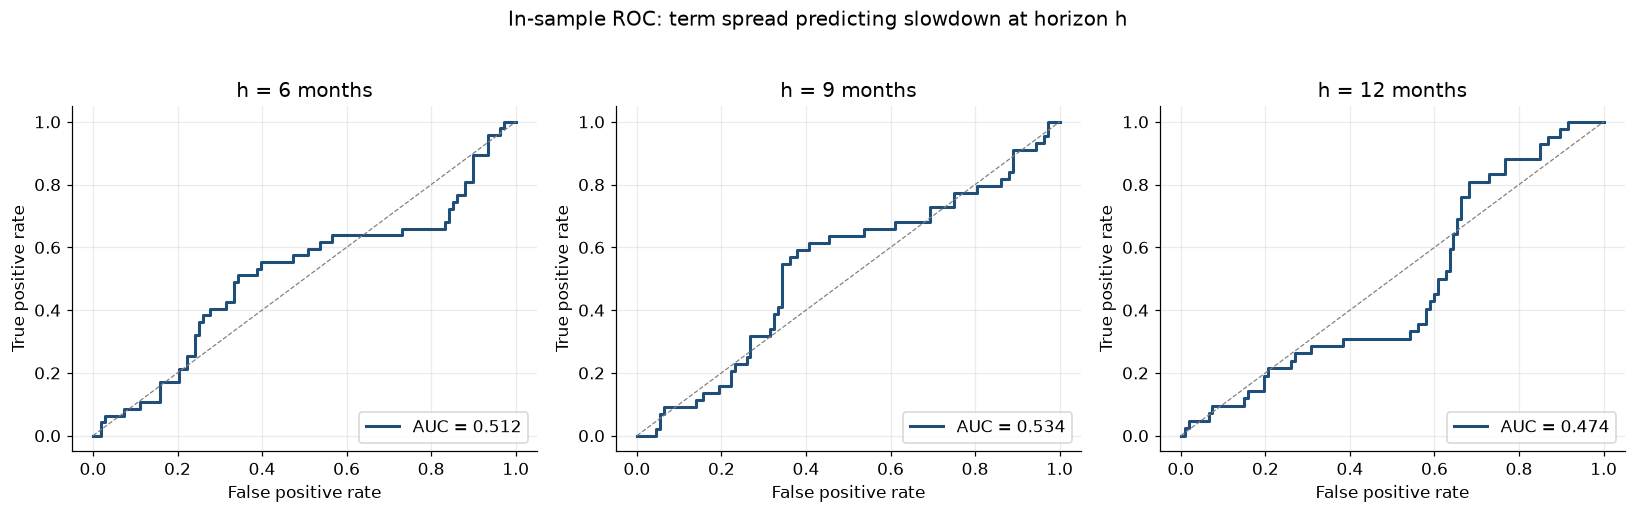

In [74]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, h in zip(axes, [6, 9, 12]):
    model, work = results_growth[h]

    X_pred = sm.add_constant(
        work[["term_spread_lag1"]],
        has_constant="add",
    )
    pred_prob = model.predict(X_pred)

    fpr, tpr, _ = roc_curve(work["target_led"], pred_prob)
    auc = roc_auc_score(work["target_led"], pred_prob)

    ax.plot(
        fpr,
        tpr,
        color="#1f4e79",
        lw=2,
        label=f"AUC = {auc:.3f}",
    )
    ax.plot([0, 1], [0, 1], color="gray", lw=0.8, ls="--")
    ax.set_title(f"h = {h} months")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.legend(loc="lower right")

plt.suptitle(
    "In-sample ROC: term spread predicting slowdown at horizon h",
    y=1.03,
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_growth_slowdown.png", bbox_inches="tight")
plt.show()

## 9. RBI cut prediction

Target: whether the RBI cuts the repo rate at least once in the **next six months**.

Because the event history ends in December 2025, observations are only retained when their complete six-month forward window is covered by that history. This prevents incomplete-window zeros.

In [75]:
cut_dates = repo_changes.loc[
    repo_changes["direction"] == "cut",
    "date"
].sort_values()

EVENT_HISTORY_END = repo_changes["date"].max()
RBI_WINDOW_MONTHS = 6

def cuts_within_window(as_of_date, window_months=6):
    window_end = as_of_date + pd.DateOffset(months=window_months)
    return int(
        (
            (cut_dates > as_of_date)
            & (cut_dates <= window_end)
        ).any()
    )

rbi_analysis = analysis_df.loc[
    analysis_df.index <= (
        EVENT_HISTORY_END - pd.DateOffset(months=RBI_WINDOW_MONTHS)
    )
].copy()

rbi_analysis["rbi_cuts_next_2q"] = [
    cuts_within_window(d, RBI_WINDOW_MONTHS)
    for d in rbi_analysis.index
]

print(
    f"RBI target sample: {rbi_analysis.index[0].date()} "
    f"to {rbi_analysis.index[-1].date()} "
    f"({len(rbi_analysis)} observations)"
)
print(
    "Share followed by an RBI cut within six months: "
    f"{rbi_analysis['rbi_cuts_next_2q'].mean():.1%}"
)

RBI target sample: 2012-01-01 to 2025-05-01 (161 observations)
Share followed by an RBI cut within six months: 47.2%


In [76]:
X_cols = ["term_spread_lag1", "cpi_yoy_lag1"]

rbi_work = rbi_analysis.dropna(
    subset=X_cols + ["rbi_cuts_next_2q"]
).copy()

X_rbi = sm.add_constant(rbi_work[X_cols], has_constant="add")
y_rbi = rbi_work["rbi_cuts_next_2q"].astype(int)

if y_rbi.nunique() < 2:
    raise ValueError("RBI target has only one class in the usable sample.")

model_rbi = sm.Logit(y_rbi, X_rbi).fit(
    disp=False,
    cov_type="HAC",
    cov_kwds={"maxlags": RBI_WINDOW_MONTHS},
)

print(model_rbi.summary2().tables[1])
print(f"\nMcFadden pseudo R-squared: {model_rbi.prsquared:.4f}")

mfx = model_rbi.get_margeff(at="overall")
print("\nAverage marginal effects:")
print(mfx.summary())

                   Coef.  Std.Err.       z  P>|z|  [0.025  0.975]
const             0.2531    0.8611  0.2939 0.7689 -1.4348  1.9409
term_spread_lag1 -0.5656    0.3329 -1.6989 0.0893 -1.2182  0.0869
cpi_yoy_lag1      0.0161    0.1359  0.1183 0.9058 -0.2503  0.2824

McFadden pseudo R-squared: 0.0620

Average marginal effects:
        Logit Marginal Effects       
Dep. Variable:       rbi_cuts_next_2q
Method:                          dydx
At:                           overall
                      dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
term_spread_lag1    -0.1294      0.066     -1.973      0.048      -0.258      -0.001
cpi_yoy_lag1         0.0037      0.031      0.119      0.906      -0.057       0.064


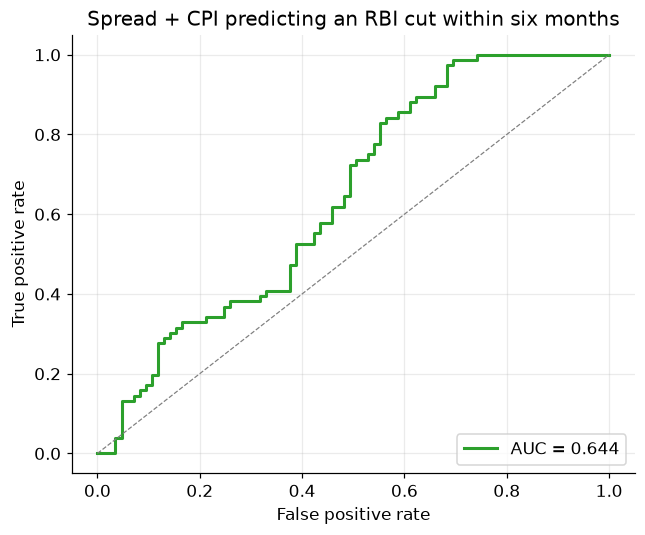

In [77]:
pred_prob_rbi = model_rbi.predict(X_rbi)
fpr, tpr, _ = roc_curve(y_rbi, pred_prob_rbi)
auc_rbi = roc_auc_score(y_rbi, pred_prob_rbi)

plt.figure(figsize=(6, 5))
plt.plot(
    fpr,
    tpr,
    color="#2ca02c",
    lw=2,
    label=f"AUC = {auc_rbi:.3f}",
)
plt.plot([0, 1], [0, 1], color="gray", lw=0.8, ls="--")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Spread + CPI predicting an RBI cut within six months")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_rbi_cut.png", bbox_inches="tight")
plt.show()

## 10. Regime-switching layer

Two- and three-regime Markov-switching models are estimated on the term spread for descriptive state characterization.

For the forward-looking regime comparison, a **pre-specified two-regime model** is re-estimated expanding-window at each evaluation date. The low-spread state is identified using only the training sample available at that date, and the final filtered probability is retained. This prevents full-sample parameter and regime-label look-ahead.

In [78]:
spread_series = analysis_df["term_spread"].dropna().astype(float)

# Full-sample models are still estimated for descriptive regime identification.
mod_2regime = MarkovRegression(
    spread_series,
    k_regimes=2,
    trend="c",
    switching_variance=True,
)
res_2regime = mod_2regime.fit()

mod_3regime = MarkovRegression(
    spread_series,
    k_regimes=3,
    trend="c",
    switching_variance=True,
)
res_3regime = mod_3regime.fit()

print(res_2regime.summary())
print(res_3regime.summary())

print(
    f"\n2-regime log-likelihood: {res_2regime.llf:.2f} | "
    f"AIC: {res_2regime.aic:.2f}"
)
print(
    f"3-regime log-likelihood: {res_3regime.llf:.2f} | "
    f"AIC: {res_3regime.aic:.2f}"
)

                        Markov Switching Model Results                        
Dep. Variable:            term_spread   No. Observations:                  161
Model:               MarkovRegression   Log Likelihood                -162.590
Date:                Thu, 13 Aug 2026   AIC                            337.180
Time:                        19:32:21   BIC                            355.669
Sample:                    01-01-2012   HQIC                           344.688
                         - 05-01-2025                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1498      0.040      3.710      0.000       0.071       0.229
sigma2         0.1012      0.019      5.469      0.0

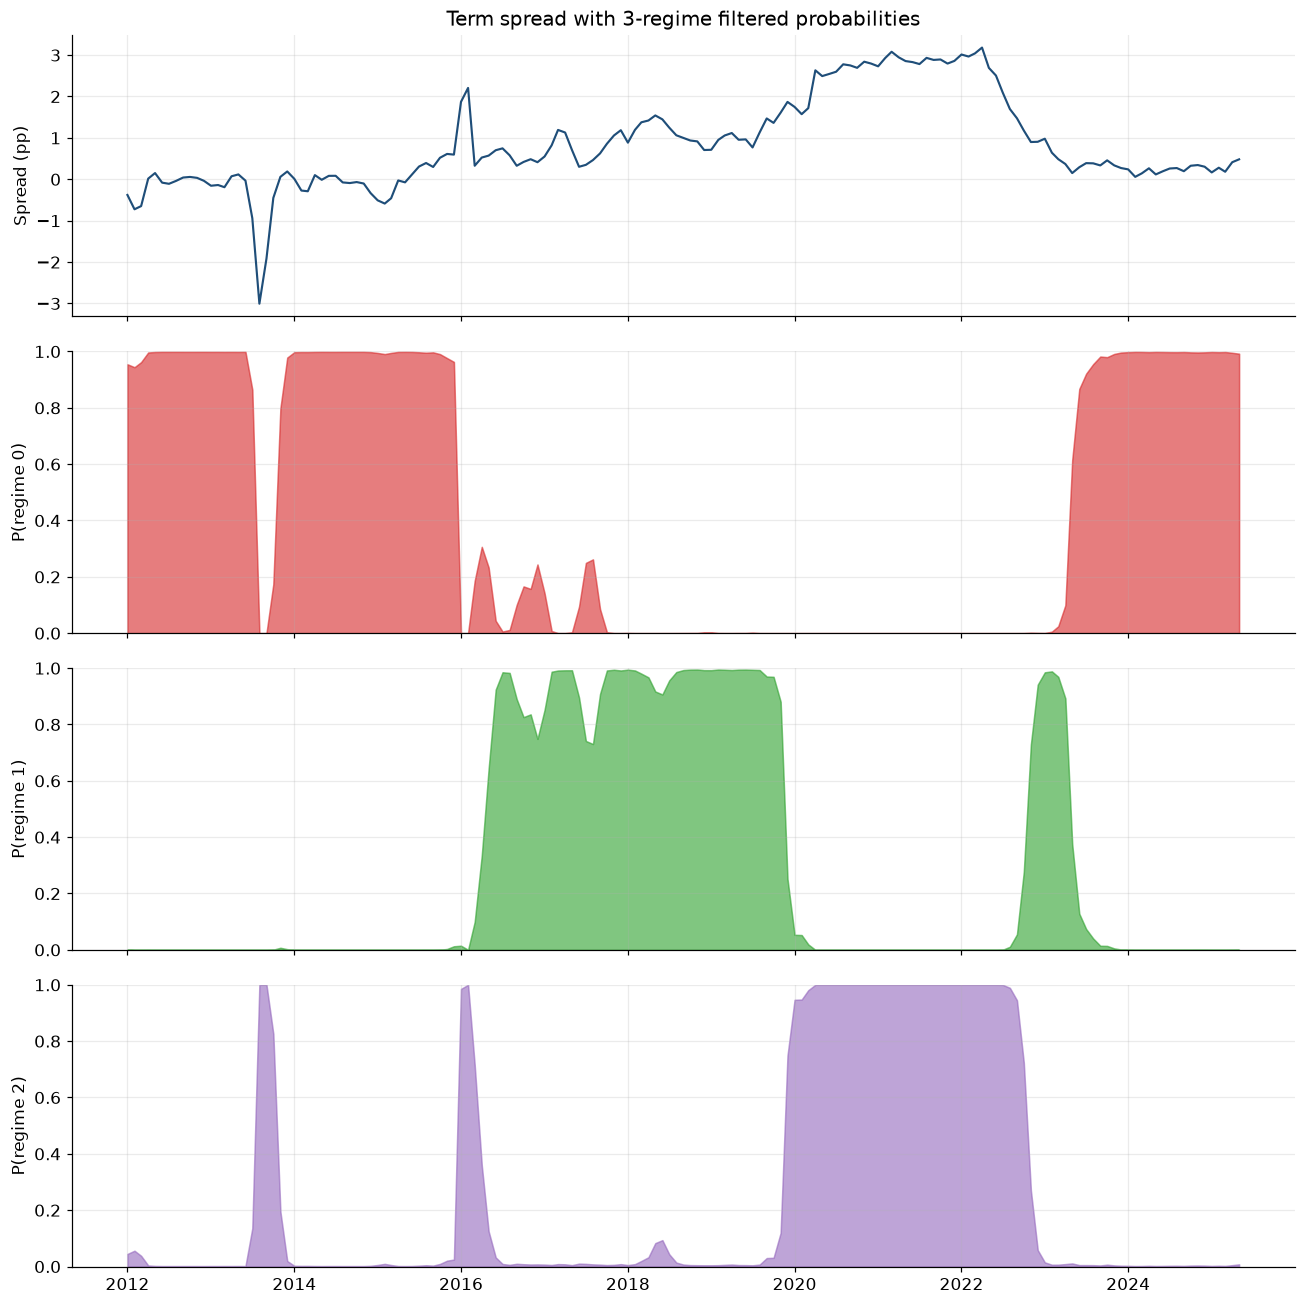

Real-time expanding-window low-regime probabilities computed for 102 evaluation months.


In [79]:
# Full-sample regime comparison is descriptive only.
best_res, best_k = (
    (res_2regime, 2)
    if res_2regime.aic <= res_3regime.aic
    else (res_3regime, 3)
)

descriptive_filtered_probs = best_res.filtered_marginal_probabilities

fig, axes = plt.subplots(
    best_k + 1,
    1,
    figsize=(12, 3 * (best_k + 1)),
    sharex=True,
)

axes[0].plot(
    spread_series.index,
    spread_series.values,
    color="#1f4e79",
    lw=1.4,
)
axes[0].set_title(
    f"Term spread with {best_k}-regime filtered probabilities"
)
axes[0].set_ylabel("Spread (pp)")

colors = ["#d62728", "#2ca02c", "#9467bd"]

for j in range(best_k):
    axes[j + 1].fill_between(
        descriptive_filtered_probs.index,
        descriptive_filtered_probs[j],
        color=colors[j % len(colors)],
        alpha=0.6,
    )
    axes[j + 1].set_ylabel(f"P(regime {j})")
    axes[j + 1].set_ylim(0, 1)

axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "regime_probabilities.png", bbox_inches="tight")
plt.show()

# Predictive regime analysis uses a pre-specified two-regime model.
REALTIME_K = 2
MIN_TRAIN_OBS = 60

real_time_low_prob = pd.Series(
    np.nan,
    index=spread_series.index,
    name="p_low_regime",
)

for end_idx in range(MIN_TRAIN_OBS - 1, len(spread_series)):
    train = spread_series.iloc[: end_idx + 1]

    model = MarkovRegression(
        train,
        k_regimes=REALTIME_K,
        trend="c",
        switching_variance=True,
    )

    try:
        result = model.fit(disp=False)
        filtered = result.filtered_marginal_probabilities

        # Identify the low-spread regime using only information in the
        # training sample for this forecast date.
        train_means = {}
        for regime in range(REALTIME_K):
            p = pd.Series(
                filtered[regime],
                index=train.index,
            ).fillna(0.0)

            if p.sum() > 0:
                train_means[regime] = np.average(
                    train,
                    weights=p,
                )

        if len(train_means) == REALTIME_K:
            low_idx = min(train_means, key=train_means.get)
            real_time_low_prob.iloc[end_idx] = float(
                filtered[low_idx].iloc[-1]
            )

    except Exception:
        continue

print(
    f"Real-time expanding-window low-regime probabilities computed for "
    f"{real_time_low_prob.notna().sum()} evaluation months."
)

In [80]:
# Descriptive full-sample regime means. Predictive regime labels are mapped
# separately inside each expanding-window fit.
descriptive_regime_means = {}

for j in range(best_k):
    p = pd.Series(
        descriptive_filtered_probs[j],
        index=spread_series.index,
    ).fillna(0.0)

    valid = spread_series.notna() & p.notna()

    descriptive_regime_means[j] = np.average(
        spread_series.loc[valid],
        weights=p.loc[valid],
    )

print(
    "Probability-weighted descriptive regime means:",
    descriptive_regime_means,
)

Probability-weighted descriptive regime means: {0: np.float64(0.07458437784114333), 1: np.float64(0.8995522974031152), 2: np.float64(2.1045484428609353)}


### Regime probabilities versus future outcomes

The filtered probability at month *t* is compared with the slowdown indicator nine months later.
For the RBI comparison, only the bounded RBI target sample is used.

In [81]:
regime_check = pd.DataFrame({
    "p_low_regime": real_time_low_prob,
    "is_slowdown_lead9": analysis_df["is_slowdown"].shift(-9),
    "rbi_cuts_next_2q": rbi_analysis["rbi_cuts_next_2q"],
}).dropna()

corr_growth = regime_check["p_low_regime"].corr(
    regime_check["is_slowdown_lead9"]
)
corr_rbi = regime_check["p_low_regime"].corr(
    regime_check["rbi_cuts_next_2q"]
)

print(
    f"Correlation, expanding-window P(low regime) vs. "
    f"slowdown 9 months later: {corr_growth:.3f}"
)
print(
    f"Correlation, expanding-window P(low regime) vs. "
    f"RBI cut within six months: {corr_rbi:.3f}"
)
print(
    "\nThese are consistency checks, not standalone forecasting models."
)

Correlation, expanding-window P(low regime) vs. slowdown 9 months later: -0.301
Correlation, expanding-window P(low regime) vs. RBI cut within six months: -0.300

These are consistency checks, not standalone forecasting models.



## 11. Pseudo-out-of-sample forecasting check

The in-sample regressions are retained for interpretation, but a separate expanding-window
evaluation is used to answer the more demanding forecasting question.

At each forecast date, the logit is estimated using only information available through that date.
No future target observations or later parameter estimates enter the forecast.


In [82]:
def expanding_window_logit_auc(
    df_in,
    predictor_cols,
    target_col,
    horizon_months,
    min_train_obs=60,
):
    work = df_in.copy()
    work["target_date"] = (
        work.index + pd.DateOffset(months=horizon_months)
    )
    work = work.dropna(
        subset=predictor_cols + [target_col]
    ).copy()

    predictions = []

    for i in range(min_train_obs, len(work)):
        forecast_date = work.index[i]

        # Only use training observations whose future target was already
        # realized by the forecast origin.
        train = work.loc[
            work["target_date"] <= forecast_date
        ].copy()
        test = work.iloc[i:i + 1].copy()

        if len(train) < min_train_obs:
            continue

        y_train = train[target_col].astype(int)
        if y_train.nunique() < 2:
            continue

        X_train = sm.add_constant(
            train[predictor_cols],
            has_constant="add",
        )
        X_test = sm.add_constant(
            test[predictor_cols],
            has_constant="add",
        )

        try:
            model = sm.Logit(y_train, X_train).fit(
                disp=False,
                maxiter=200,
            )
            prob = float(model.predict(X_test).iloc[0])

            predictions.append(
                {
                    "date": forecast_date,
                    "actual": int(test[target_col].iloc[0]),
                    "probability": prob,
                }
            )
        except Exception:
            continue

    if not predictions:
        return pd.DataFrame(
            columns=["actual", "probability"],
            index=pd.DatetimeIndex([], name="date"),
        ), np.nan

    pred_df = pd.DataFrame(predictions).set_index("date")

    if pred_df["actual"].nunique() < 2:
        return pred_df, np.nan

    auc = roc_auc_score(
        pred_df["actual"],
        pred_df["probability"],
    )

    return pred_df, auc


oos_growth = {}

for h in [6, 9, 12]:
    pred_df, auc = expanding_window_logit_auc(
        analysis_df,
        ["term_spread_lag1"],
        "is_slowdown",
        h,
    )
    oos_growth[h] = pred_df

    if pd.notna(auc):
        print(
            f"Growth slowdown h={h}: "
            f"pseudo-out-of-sample AUC = {auc:.3f}"
        )
    else:
        print(
            f"Growth slowdown h={h}: insufficient target variation "
            f"for an AUC estimate."
        )

Growth slowdown h=6: pseudo-out-of-sample AUC = 0.347
Growth slowdown h=9: pseudo-out-of-sample AUC = 0.268
Growth slowdown h=12: pseudo-out-of-sample AUC = 0.239


## 12. Robustness checks

The key robustness check excludes the COVID period.

The same target definitions and information-set restrictions are retained.

In [83]:
N = len(analysis_df)
print(
    f"Full historical analysis sample: {N} months "
    f"({analysis_df.index[0].date()} to {analysis_df.index[-1].date()})"
)

COVID_START = pd.Timestamp("2020-02-01")
COVID_END = pd.Timestamp("2020-12-01")

ex_covid = analysis_df[
    (analysis_df.index < COVID_START)
    | (analysis_df.index > COVID_END)
].copy()

print(
    f"Excluding COVID window: {len(ex_covid)} months remain."
)

model_ex_covid, work_ex_covid_growth = run_lead_logit(
    ex_covid,
    ["term_spread_lag1"],
    "is_slowdown",
    horizon_months=9,
)

print("\nGrowth-slowdown model at h=9, excluding COVID:")
print(model_ex_covid.summary2().tables[1])
print(
    f"McFadden pseudo R-squared: {model_ex_covid.prsquared:.4f} "
    f"(full sample: {results_growth[9][0].prsquared:.4f})"
)

Full historical analysis sample: 161 months (2012-01-01 to 2025-05-01)
Excluding COVID window: 150 months remain.

Growth-slowdown model at h=9, excluding COVID:
                   Coef.  Std.Err.       z  P>|z|  [0.025  0.975]
const            -1.1435    0.4165 -2.7456 0.0060 -1.9599 -0.3272
term_spread_lag1  0.0457    0.2264  0.2019 0.8400 -0.3981  0.4895
McFadden pseudo R-squared: 0.0004 (full sample: 0.0010)


In [84]:
rbi_ex_covid = rbi_analysis[
    (rbi_analysis.index < COVID_START)
    | (rbi_analysis.index > COVID_END)
].copy()

rbi_work_ex_covid = rbi_ex_covid.dropna(
    subset=X_cols + ["rbi_cuts_next_2q"]
)

X_ec = sm.add_constant(
    rbi_work_ex_covid[X_cols],
    has_constant="add",
)
y_ec = rbi_work_ex_covid["rbi_cuts_next_2q"].astype(int)

if y_ec.nunique() >= 2:
    model_rbi_ex_covid = sm.Logit(y_ec, X_ec).fit(
        disp=False,
        cov_type="HAC",
        cov_kwds={"maxlags": RBI_WINDOW_MONTHS},
    )

    print("RBI-cut model, excluding COVID:")
    print(model_rbi_ex_covid.summary2().tables[1])
    print(
        f"McFadden pseudo R-squared: {model_rbi_ex_covid.prsquared:.4f} "
        f"(full sample: {model_rbi.prsquared:.4f})"
    )
else:
    print(
        "COVID-excluded RBI sample has only one target class; "
        "the robustness logit is not estimable."
    )

RBI-cut model, excluding COVID:
                   Coef.  Std.Err.       z  P>|z|  [0.025  0.975]
const             0.2900    0.8517  0.3405 0.7335 -1.3793  1.9593
term_spread_lag1 -0.5771    0.3543 -1.6291 0.1033 -1.2715  0.1172
cpi_yoy_lag1      0.0061    0.1332  0.0459 0.9634 -0.2550  0.2672
McFadden pseudo R-squared: 0.0564 (full sample: 0.0620)



## Methodological limitations that remain by design

These are not coding defects and are stated explicitly rather than hidden:

1. FRED provides revised historical observations, not full real-time vintages. The exercise is therefore a historical forecasting-style evaluation, not a vintage-real-time macro forecasting backtest.
2. A one-month predictor lag is used as a conservative proxy for release timing; exact release-date alignment is not available uniformly for all series used here.
3. The RBI event history is manually curated. The six-month policy target is therefore bounded by the last verified event date rather than extrapolated.
4. The manufacturing series is a production proxy, not India's headline IIP series.
5. In-sample logit estimates remain useful for structural interpretation, while the expanding-window evaluation is the appropriate section for forecasting claims.
6. Markov regimes are exploratory. The expanding-window filtered probabilities are used for forward-looking comparisons; the full-sample regime model is retained only to identify stable regime labels and provide descriptive visualization.


## 13. Final diagnostics and exports

This section performs basic integrity checks before exporting the analytical dataset.

In [85]:
required_columns = [
    "gsec_10y",
    "short_rate",
    "cpi_index",
    "growth_yoy",
    "term_spread",
    "cpi_yoy",
    "term_spread_lag1",
    "cpi_yoy_lag1",
    "is_slowdown",
]

missing_required = [
    col for col in required_columns
    if col not in analysis_df.columns
]

if missing_required:
    raise AssertionError(
        f"Missing required columns: {missing_required}"
    )

if not isinstance(analysis_df.index, pd.DatetimeIndex):
    raise AssertionError("Analysis index must be a DatetimeIndex.")

if not analysis_df.index.is_monotonic_increasing:
    raise AssertionError(
        "Analysis index is not monotonically increasing."
    )

if analysis_df.index.has_duplicates:
    raise AssertionError("Analysis index contains duplicates.")

if any(ts.day != 1 for ts in analysis_df.index):
    raise AssertionError(
        "Analysis dates are not normalized to month-start."
    )

# Validate the lag against the original source series. Critically, do not
# shift the already-filtered analysis sample.
expected_lag = df["term_spread"].shift(1).reindex(
    analysis_df.index
)

lag_check = pd.concat(
    [
        analysis_df["term_spread_lag1"].rename("actual"),
        expected_lag.rename("expected"),
    ],
    axis=1,
).dropna()

if lag_check.empty:
    raise AssertionError(
        "No overlapping observations available for lag validation."
    )

if not np.allclose(
    lag_check["actual"].to_numpy(),
    lag_check["expected"].to_numpy(),
    rtol=1e-10,
    atol=1e-12,
):
    max_diff = np.abs(
        lag_check["actual"].to_numpy()
        - lag_check["expected"].to_numpy()
    ).max()

    raise AssertionError(
        f"Term-spread lag does not match its source series. "
        f"Maximum absolute difference = {max_diff:.3e}"
    )

# The RBI target must only contain fully observable six-month windows.
rbi_cutoff = (
    EVENT_HISTORY_END
    - pd.DateOffset(months=RBI_WINDOW_MONTHS)
)

if rbi_analysis.index.max() > rbi_cutoff:
    raise AssertionError(
        "RBI target sample exceeds the fully observable forward window."
    )

# Recompute the target independently as an internal reproducibility check.
recomputed_rbi_target = pd.Series(
    [
        cuts_within_window(d, RBI_WINDOW_MONTHS)
        for d in rbi_analysis.index
    ],
    index=rbi_analysis.index,
)

if not np.array_equal(
    recomputed_rbi_target.to_numpy(),
    rbi_analysis["rbi_cuts_next_2q"].to_numpy(),
):
    raise AssertionError(
        "RBI forward-cut target failed its reproducibility check."
    )

print("All diagnostic checks passed.")

export_cols = [
    "gsec_10y",
    "short_rate",
    "cpi_index",
    "growth_yoy",
    "term_spread",
    "cpi_yoy",
    "term_spread_lag1",
    "cpi_yoy_lag1",
    "is_slowdown",
]

analysis_df[export_cols].to_csv(
    OUTPUT_DIR / "india_term_spread_dataset.csv"
)

rbi_analysis[
    export_cols + ["rbi_cuts_next_2q"]
].to_csv(
    OUTPUT_DIR / "india_rbi_cut_analysis_dataset.csv"
)

repo_changes.to_csv(
    OUTPUT_DIR / "rbi_repo_rate_changes.csv",
    index=False,
)

print("\nExported:")
print(" ", OUTPUT_DIR / "india_term_spread_dataset.csv")
print(" ", OUTPUT_DIR / "india_rbi_cut_analysis_dataset.csv")
print(" ", OUTPUT_DIR / "rbi_repo_rate_changes.csv")
print(" ", OUTPUT_DIR / "spread_vs_growth.png")
print(" ", OUTPUT_DIR / "roc_growth_slowdown.png")
print(" ", OUTPUT_DIR / "roc_rbi_cut.png")
print(" ", OUTPUT_DIR / "regime_probabilities.png")

All diagnostic checks passed.

Exported:
  output\india_term_spread_dataset.csv
  output\india_rbi_cut_analysis_dataset.csv
  output\rbi_repo_rate_changes.csv
  output\spread_vs_growth.png
  output\roc_growth_slowdown.png
  output\roc_rbi_cut.png
  output\regime_probabilities.png
